# Sample selection 

In [3]:
import pandas as pd
import subsetmask as sm
from pathlib import Path
import os
import seaborn as sns
import matplotlib.pyplot as plt

In [6]:
# %% setting paths
MAIN_DIR_NAME = "proseg_slides_meta"
MAIN_DIR = next(p for p in Path.cwd().parents if (p / MAIN_DIR_NAME).exists()) / MAIN_DIR_NAME
os.chdir(MAIN_DIR)

We use the metadata flatfile

In [7]:
# setting paths
slide_name = 'SLIDE03'
meta_path = MAIN_DIR / f'{slide_name}_meta.tsv'

In [5]:
# run this to activate qt
%gui qt

## Slide 3

In [9]:
meta = pd.read_csv(meta_path, sep='\t', index_col=0)

# remove column sample_name if it was already added
if 'sample_name' in meta.columns:
    meta = meta.drop(columns=['sample_name'])

# check columns
meta.head()

,cell,original_cell_id,centroid_x,centroid_y,centroid_z,component,volume,surface_area,scale
0,0,c_3_169_477,515.89075,1397.8613,0.278974,2,37.75,238.0,1.0
1,1,c_3_169_1204,573.66925,1075.3109,0.507692,1,32.50,230.0,1.0
2,2,c_3_169_1051,525.55000,1174.7075,0.285000,5,25.00,192.0,1.0
3,3,c_3_169_1032,522.86620,1182.0107,0.297535,2,17.75,164.0,1.0
4,4,c_3_169_1065,532.77026,1167.8450,0.452703,2,18.50,156.0,1.0


In [10]:
# add slide_ID column
meta['slide_ID'] = str(slide_name)

# add a cell_id column with slide_name + cell
meta['cell_id'] =  meta['slide_ID'] + '_' + meta['cell'].astype(str)
meta.head()

,cell,original_cell_id,centroid_x,centroid_y,centroid_z,component,volume,surface_area,scale,slide_ID,cell_id
0,0,c_3_169_477,515.89075,1397.8613,0.278974,2,37.75,238.0,1.0,SLIDE03,SLIDE03_0
1,1,c_3_169_1204,573.66925,1075.3109,0.507692,1,32.50,230.0,1.0,SLIDE03,SLIDE03_1
2,2,c_3_169_1051,525.55000,1174.7075,0.285000,5,25.00,192.0,1.0,SLIDE03,SLIDE03_2
3,3,c_3_169_1032,522.86620,1182.0107,0.297535,2,17.75,164.0,1.0,SLIDE03,SLIDE03_3
4,4,c_3_169_1065,532.77026,1167.8450,0.452703,2,18.50,156.0,1.0,SLIDE03,SLIDE03_4


In [12]:
# create the image for slide1
slide = sm.Image(metadata_df=meta, 
                  images_col='slide_ID',
                  image_name=slide_name,
                  x_col = 'centroid_x',
                  y_col = 'centroid_y',)

# add store image method
slide.store_image(group_col=None, 
                   figsize=(30,50),
                   dpi=300, 
                   dot_size=2,
                   cmap='tab20')

/Users/robin.carvajal/miniforge3/envs/subsetmask/lib/python3.10/site-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (135000000 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(


array([[[255, 255, 255, 255],
        [255, 255, 255, 255],
        [255, 255, 255, 255],
        ...,
        [255, 255, 255, 255],
        [255, 255, 255, 255],
        [255, 255, 255, 255]],

       [[255, 255, 255, 255],
        [255, 255, 255, 255],
        [255, 255, 255, 255],
        ...,
        [255, 255, 255, 255],
        [255, 255, 255, 255],
        [255, 255, 255, 255]],

       [[255, 255, 255, 255],
        [255, 255, 255, 255],
        [255, 255, 255, 255],
        ...,
        [255, 255, 255, 255],
        [255, 255, 255, 255],
        [255, 255, 255, 255]],

       ...,

       [[255, 255, 255, 255],
        [255, 255, 255, 255],
        [255, 255, 255, 255],
        ...,
        [255, 255, 255, 255],
        [255, 255, 255, 255],
        [255, 255, 255, 255]],

       [[255, 255, 255, 255],
        [255, 255, 255, 255],
        [255, 255, 255, 255],
        ...,
        [255, 255, 255, 255],
        [255, 255, 255, 255],
        [255, 255, 255, 255]],

       [[255

In [13]:
# launches napari with the generated image, ready for selection
slide.draw_labels()

<Labels layer 'Mask' at 0x35abfb160>

In [14]:
# without closing napari we run this line to save the annotations
slide.save_annotations(ann_col_name="sample_name")

# we change our annotations for something more meaningful
map = {
    "label_1": "CTRL01",
    "label_2": "CTRL02",
    "label_3": "PWCF05"
}

slide.rename_annotations(ann_col_name="sample_name", mapping_dict=map)

# we extract the annotated df from the object
annotated_meta_slide = slide.annotated_metadata_df

# check the annotated metadata
annotated_meta_slide.head()


,cell,original_cell_id,centroid_x,centroid_y,centroid_z,component,volume,surface_area,scale,slide_ID,cell_id,sample_name
0,0,c_3_169_477,515.89075,1397.8613,0.278974,2,37.75,238.0,1.0,SLIDE03,SLIDE03_0,PWCF05
1,1,c_3_169_1204,573.66925,1075.3109,0.507692,1,32.50,230.0,1.0,SLIDE03,SLIDE03_1,PWCF05
2,2,c_3_169_1051,525.55000,1174.7075,0.285000,5,25.00,192.0,1.0,SLIDE03,SLIDE03_2,PWCF05
3,3,c_3_169_1032,522.86620,1182.0107,0.297535,2,17.75,164.0,1.0,SLIDE03,SLIDE03_3,PWCF05
4,4,c_3_169_1065,532.77026,1167.8450,0.452703,2,18.50,156.0,1.0,SLIDE03,SLIDE03_4,PWCF05


check

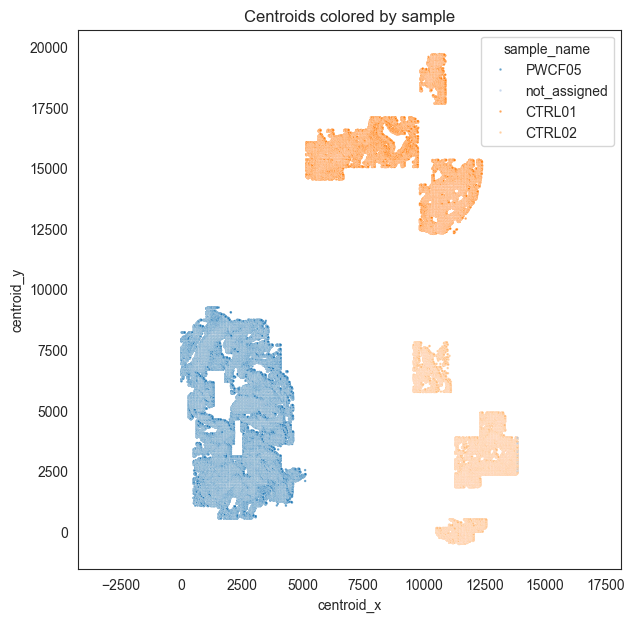

In [15]:
# scater plot using matplot lib
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 7))
sns.set_style("white")
sns.scatterplot(
    data=annotated_meta_slide,
    x="centroid_x",
    y="centroid_y",
    hue="sample_name",        # or "library_id", etc.
    s=3,
    alpha=0.7,
    palette="tab20"      # or any seaborn/matplotlib palette
)
plt.axis("equal")
plt.title("Centroids colored by sample")
plt.show()

In [16]:
annotated_meta_slide.groupby(["slide_ID", "sample_name"]).size().reset_index(name="count")

,slide_ID,sample_name,count
0,SLIDE03,CTRL01,81664
1,SLIDE03,CTRL02,55175
2,SLIDE03,PWCF05,213776
3,SLIDE03,not_assigned,22


## save the annotated metadata

In [17]:
# Save the annotated metadata
annotated_meta_slide.to_csv(meta_path, index=False)

In [18]:
# check if the saved file is correct
meta = pd.read_csv(meta_path)
meta

,cell,original_cell_id,centroid_x,centroid_y,centroid_z,component,volume,surface_area,scale,slide_ID,cell_id,sample_name
0,0,c_3_169_477,515.89075,1397.8613,0.278974,2,37.75,238.0,1.0,SLIDE03,SLIDE03_0,PWCF05
1,1,c_3_169_1204,573.66925,1075.3109,0.507692,1,32.50,230.0,1.0,SLIDE03,SLIDE03_1,PWCF05
2,2,c_3_169_1051,525.55000,1174.7075,0.285000,5,25.00,192.0,1.0,SLIDE03,SLIDE03_2,PWCF05
3,3,c_3_169_1032,522.86620,1182.0107,0.297535,2,17.75,164.0,1.0,SLIDE03,SLIDE03_3,PWCF05
4,4,c_3_169_1065,532.77026,1167.8450,0.452703,2,18.50,156.0,1.0,SLIDE03,SLIDE03_4,PWCF05
...,...,...,...,...,...,...,...,...,...,...,...,...
350632,350632,c_3_2_71,10826.87200,19665.4980,0.232664,2,34.25,190.0,1.0,SLIDE03,SLIDE03_350632,CTRL01
350633,350633,c_3_2_119,10829.90300,19653.8280,0.257102,6,44.00,222.0,1.0,SLIDE03,SLIDE03_350633,CTRL01
350634,350634,c_3_2_117,10843.84300,19656.1200,0.206081,5,27.75,164.0,1.0,SLIDE03,SLIDE03_350634,CTRL01
350635,350635,c_3_2_97,10838.86800,19661.3340,0.300439,2,14.25,134.0,1.0,SLIDE03,SLIDE03_350635,CTRL01
